In [1]:
%matplotlib inline

In [2]:

import warnings
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.cm as cm
from scipy.io import loadmat
import scipy
from sklearn.manifold import LocallyLinearEmbedding
import nilearn as nl             # pip: nilearn==0.10.0
from nilearn.maskers import NiftiMasker
import nibabel as nib
import nltools as nlt
from matplotlib.colors import ListedColormap




In [49]:

################################################################################
# Archetypal Analysis        ####################################################
################################################################################
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin


class ArchetypalAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, n_archetypes=None, tmax=20, iterations=10):
        '''
        Implements archetypal analysis
            Archetypal Analysis as an Autoencoder (Bauckhage et al. 2015)

        Parameters
        ----------

        n_archetypes : the number of archetype

        tmax : the number of iterations of the derivative update

        iterations : the number of iterations of the overall algorithm


        Notes
        ---------

        The matrices have the following dimensions (following the above paper)
        [X] - m x n
        [Z] - m x k
        [B] - n x k
        [A] - k x n
        [e_A] - k x 1
        [e_B] - n x 1

        Source: https://miller-blog.com/archetypal-analysis/

        '''
        self.n_archetypes = n_archetypes
        self.tmax = tmax
        self.iterations = iterations

        N = self.n_archetypes
        x, y = np.zeros(N), np.zeros(N)
        x[1:] = np.cumsum(np.cos(np.arange(0, N - 1) * 2 * np.pi / N))
        y[1:] = np.cumsum(np.sin(np.arange(0, N - 1) * 2 * np.pi / N))
        self.map2D = np.vstack((x, y))

    def fit(self, X, y=None):
        """Fit the model with X using Archetypal Analysis
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data, where n_samples is the number of samples
            and n_features is the number of features.
        y : Ignored
        Returns
        -------
        self : object
            Returns the instance itself.

        Source: https://miller-blog.com/archetypal-analysis/
        """
        self._fit(X)
        return self

    def _fit(self, X):
        k = self.n_archetypes
        m, n = X.shape

        B = np.eye(n, k)
        Z = X @ B

        for i in range(self.iterations):
            A = self._computeA(X, Z, self.tmax)
            B = self._computeB(X, A, self.tmax)
            Z = X @ B
            print('RSS = {}'.format(self._rss(X, A, Z)))

        self.Z_ = Z
        self.A_ = A

    def _computeA(self, X, Z, tmax):
        '''
        Algorithm 1 of Bauckhage et al. 2015
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        m, n = X.shape
        k = self.n_archetypes

        A = np.zeros((k, n))
        A[0, :] = 1.0
        for t in range(tmax):
            # brackets are important to get reasonable sizes
            # [G] ~  k x n
            G = 2.0 * ((Z.T @ Z) @ A - Z.T @ X)
            # Get the argument mins along each column
            argmins = np.argmin(G, axis=0)
            e = np.zeros(G.shape)
            e[argmins, range(n)] = 1.0
            A += 2.0 / (t + 2.0) * (e - A)
        return A

    def _computeB(self, X, A, tmax):
        '''
        Algorithm 2 of Bauckhage et al. 2015
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        k, n = A.shape
        B = np.zeros((n, k))
        B[0, :] = 1.0
        for t in range(tmax):
            # brackets are important to get reasonable sizes
            t1 = X.T @ (X @ B) @ (A @ A.T)
            t2 = X.T @ (X @ A.T)
            G = 2.0 * (t1 - t2)
            argmins = np.argmin(G, axis=0)
            e = np.zeros(G.shape)
            e[argmins, range(k)] = 1.0
            B += 2.0 / (t + 2.0) * (e - B)
        return B

    def archetypes(self):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return self.Z_

    def transform(self, X):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return self._computeA(X, self.Z_, self.tmax)

    def inverse_transform(self, X):

        return np.dot(self.Z_, X.T).T

    def _rss(self, X, A, Z):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return np.linalg.norm(X - Z @ A)

    def score(self, X):

        return self._rss(X, self.A_, self.Z_)

def archetypal_plot(ax, data, dp, epsilon=0.2):
    '''
    Source: Dr. Luke Bovard
    '''
    ax.scatter(data[0, :], data[1, :], alpha=0.6, linewidths=10)
    ax.scatter(dp[0, :], dp[1, :], c='orange')

    for i in range(dp.shape[1]):
        if dp[0, i] < 0.5:
            eps_x = -epsilon
        else:
            eps_x = epsilon
        if dp[1, i] < np.max(dp[1, :]) / 2.0:
            eps_y = -epsilon
        else:
            eps_y = epsilon
        ax.text(dp[0, i] + eps_x, dp[1, i] + eps_y, "{}".format(i + 1))
    return ax

In [4]:

def nii2cmu(nifti_file, mask_file=None):
    '''
    inputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename of a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output.  If ignored or set to None, no voxels will
                 be masked out.

    outputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.
    '''
    def fullfact(dims):
        '''
        Replicates MATLAB's fullfact function (behaves the same way)
        '''
        vals = np.asmatrix(range(1, dims[0] + 1)).T
        if len(dims) == 1:
            return vals
        else:
            aftervals = np.asmatrix(fullfact(dims[1:]))
            inds = np.asmatrix(np.zeros((np.prod(dims), len(dims))))
            row = 0
            for i in range(aftervals.shape[0]):
                inds[row:(row + len(vals)), 0] = vals
                inds[row:(row + len(vals)), 1:] = np.tile(aftervals[i, :], (len(vals), 1))
                row += len(vals)
            return inds

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if type(nifti_file) == str:
            img = nib.load(nifti_file)
        elif type(nifti_file) == nib.nifti1.Nifti1Image:
            img = nifti_file
        else:
            raise ValueError('nifti_file must be a filename or nibabel Nifti1Image object')

        mask = NiftiMasker(mask_strategy='background')
        if mask_file is None:
            mask.fit(nifti_file)
        else:
            mask.fit(mask_file)

    hdr = img.header
    S = img.get_sform()
    vox_size = hdr.get_zooms()
    im_size = img.shape

    if len(img.shape) > 3:
        N = img.shape[3]
    else:
        N = 1

    Y = np.float32(mask.transform(nifti_file)).copy()
    vmask = np.nonzero(np.array(np.reshape(mask.mask_img_.dataobj, (1, np.prod(mask.mask_img_.shape)), order='C')))[1]
    vox_coords = fullfact(img.shape[0:3])[vmask, ::-1]-1

    R = np.array(np.dot(vox_coords, S[0:3, 0:3])) + S[:3, 3]

    return {'Y': Y, 'R': R}

def cmu2nii(Y, R, template=None):
    '''
    inputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.

      template: a filename of a .nii or .nii.gz file to be used as an image
                template.  Header information of the outputted nifti images will
                be read from the header file.  If this argument is ignored or
                set to None, header information will be inferred based on the
                R array.

    outputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename for a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output

    outputs:
      img: a nibabel Nifti1Image object containing the fMRI data
    '''
    Y = np.array(Y, ndmin=2)
    img = nib.load(template)
    S = img.affine
    locs = np.array(np.dot(R - S[:3, 3], np.linalg.inv(S[0:3, 0:3])), dtype='int')

    data = np.zeros(tuple(list(img.shape)[0:3]+[Y.shape[0]]))

    # loop over data and locations to fill in activations
    for i in range(Y.shape[0]):
        for j in range(R.shape[0]):
            data[locs[j, 0], locs[j, 1], locs[j, 2], i] = Y[i, j]

    return nib.Nifti1Image(data, affine=img.affine)
    
    
# def cmu2nii(activations, locations, template):
#     image = nib.load(template)
#     sform = image.get_sform()
#     coords = np.round(np.array(
#         np.dot(locations - sform[:3, 3],
#                np.linalg.inv(sform[0:3, 0:3]))
#     )).astype(int)
#     data = np.zeros(image.shape[0:3] + (activations.shape[0],))

#     for i in range(activations.shape[0]):
#         for j in range(locations.shape[0]):
#             x, y, z = coords[j, 0], coords[j, 1], coords[j, 2]
#             data[x, y, z, i] = activations[i, j]

#     return nib.Nifti1Image(data, affine=image.get_sform())

def node_labels(centers, widths, networks_cmu):
    labels = []
    for c, w in zip(centers, widths):
        r = rbf(networks_cmu['R'], c, w)

        label_weights = [sum(r[networks_cmu['Y'].ravel() == i]) for i in range(1, len(network_codes) + 1)]
        labels.append(np.argmax(label_weights) + 1)

    return pd.DataFrame({'code': labels, 'Network': [list(lookup_table.values())[i - 1] for i in labels]})

def rbf(R, center, width):
    return np.exp(-np.sum((R - center) ** 2, axis=1) / width)

def purity(y_clust,y_class):

    size_clust = np.max(y_clust)
    len_clust = len(y_clust)
    clusters_labels_try = [None] * size_clust

    for i in range(len_clust):
        index = y_clust[i]
    
        if clusters_labels_try[index-1] is None:
            clusters_labels_try[index-1] = y_class[i]

        else:
            clusters_labels_try[index-1] = np.hstack((clusters_labels_try[index-1], y_class[i]))
    purity = 0
    for c in clusters_labels_try:
        c = c.astype(int)
        if isinstance(c, np.int64):
    
            c = np.array([c]) 
        y = np.bincount(c) #I find occurrences of the present elements
        maximum = np.max(y) #I take the item more frequently
        purity += maximum

    purity = purity/len_clust

    return purity

# Here's a mini analysis with some example fmri data

# Pie Man Data

## Load the data here

The data we're using for this, to start, is fMRI data from particpants scanned while being told a story in different listening conditions.  The story was told either intact, or scrambled by the paragraph, or scrambled by the word, or just while the participant was quietly resting.  

The fMRI data was then reduced using Hierarchicaly topographic factor analysis (HTFA which is a Bayesian factor analysis model designed to analyze brain network dynamics in multi-subject datasets. It builds upon Topographic Factor Analysis (TFA), extending it to incorporate data from multiple subjects, allowing for the identification of shared brain network hubs and the comparison of individual subject's brain activity against a global template. In this case, the >100,000 voxels was reduced to 700 nodes with varying widths.




In [6]:
pieman_name = '../data/raw/pieman_data.mat'
pieman_data = loadmat(pieman_name)
pieman_conds = ['intact', 'paragraph', 'word', 'rest']

In [7]:
posterior = loadmat('../data/raw/pieman_posterior_K700.mat')
centers = posterior['posterior']['centers'][0][0][0][0][0]
widths = np.array(list(posterior['posterior']['widths'][0][0][0][0][0][:, 0].T))

These lines of code separate the participant data by listening conditions (and skips over one participant with an incorrect number of timepoints in the paragraph condition)

In [8]:
data = []
conds = []
for c in pieman_conds:
    if c == 'paragraph':
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.where(np.arange(pieman_data[c].shape[1]) != 3)[0]))
    else:
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.arange(pieman_data[c].shape[1])))
    data.extend(next_data)
    conds.extend([c]*len(next_data))


In [9]:
conds_array = np.array(conds)

First, lets just play with some of the intact listening condition data:

In [10]:
intact_list = [data[i] for i in np.where(conds_array=='intact')[0]]
intact_array = np.array(intact_list)

In [11]:
paragraph_list = [data[i] for i in np.where(conds_array=='paragraph')[0]]
paragraph_array = np.array(paragraph_list)

In [12]:
word_list = [data[i] for i in np.where(conds_array=='word')[0]]
word_array = np.array(word_list)

In [13]:
rest_list = [data[i] for i in np.where(conds_array=='rest')[0]]
rest_array = np.array(rest_list)

And lets perform an archetypal analysis on just the first participant in that group:

## Network Analysis

Let's load in what we need for our network analysis:

In [16]:
key = os.path.join('../data/raw/Schaefer2018_1000Parcels_7Networks_order.txt')
key = pd.read_csv(key, sep='\t', header=None, names=['id', 'name', 'x', 'y', 'z', 't']).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)

lookup_table = {
    'Vis': 'Visual',
    'SomMot': 'Somatomotor',
    'DorsAttn': 'Dorsal attention',
    'SalVentAttn': 'Ventral attention',
    'Limbic': 'Limbic',
    'Cont': 'Frontoparietal',
    'Default': 'Default mode'
}

network_colors = {
    'Visual': '#D7DF23',
    'Somatomotor': '#39B54A',
    'Dorsal attention': '#00A79D',
    'Ventral attention': '#27AAE1',
    'Limbic': '#1C75BC',
    'Frontoparietal': '#92278F',
    'Default mode': '#EE2A7B'
}

colors = ['#888888']
colors.extend([v for k, v in network_colors.items()])
network_cmap = ListedColormap(colors, N=len(colors)*2, name='networks')  # why do I need to double the number of colors?

network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}

key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0  # append a background (non-network) code
key           # pip: nibabel==5.0.1

,x,y,z,study,hemisphere,network,code
id,,,,,,,
1,120.0,14.0,127.0,7Networks,L,Visual,1.0
2,120.0,14.0,128.0,7Networks,L,Visual,1.0
3,120.0,14.0,129.0,7Networks,L,Visual,1.0
4,120.0,14.0,130.0,7Networks,L,Visual,1.0
5,120.0,14.0,131.0,7Networks,L,Visual,1.0
...,...,...,...,...,...,...,...
997,208.0,65.0,82.0,7Networks,R,Default mode,7.0
998,208.0,65.0,83.0,7Networks,R,Default mode,7.0
999,235.0,149.0,37.0,7Networks,R,Frontoparietal,6.0


In [17]:
nii_fname = os.path.join('../data/raw/Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz')


So this is a plot of the 7 networks in the brain determined by Yeo et al. (2017).  

<Figure size 640x480 with 0 Axes>

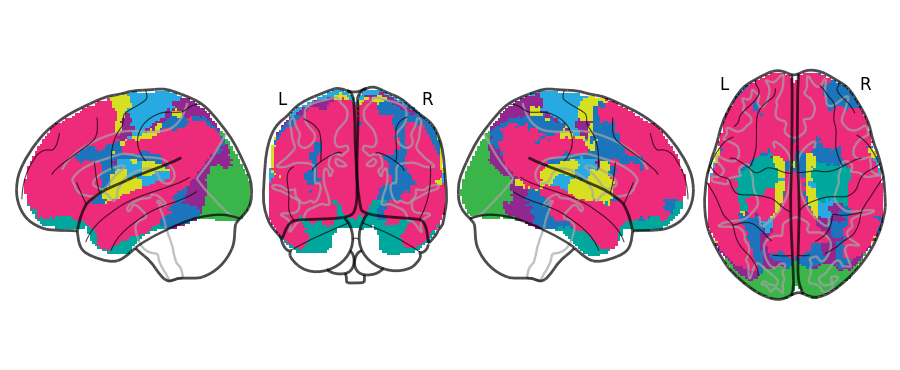

In [23]:
nx = nlt.Brain_Data(nii_fname)
nx.data = np.array([key.loc[i, 'code'] for i in nx.data]).astype(float)
networks = nx.to_nifti()
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz')
plt.show()
plt.clf()


We need a way to map our 700 nodes to these networks:

In [24]:
# load network parcellations in CMU format
networks_cmu = nii2cmu(nii_fname)

# covert voxel values in the reference image to network codes
networks_cmu['Y'] = np.atleast_2d(np.array([key.loc[i, 'code'] for i in networks_cmu['Y']]).astype(float))

And these are the labels/code for each of those nodes:

In [25]:
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

,code,Network
0,4,Ventral attention
1,3,Dorsal attention
2,1,Visual
3,6,Frontoparietal
4,4,Ventral attention
...,...,...
695,2,Somatomotor
696,4,Ventral attention
697,4,Ventral attention
698,4,Ventral attention


Ok and plot that now (we could vary the node size relative to the width, but just for simplicity the nodes are all the same size here).

<Figure size 640x480 with 0 Axes>

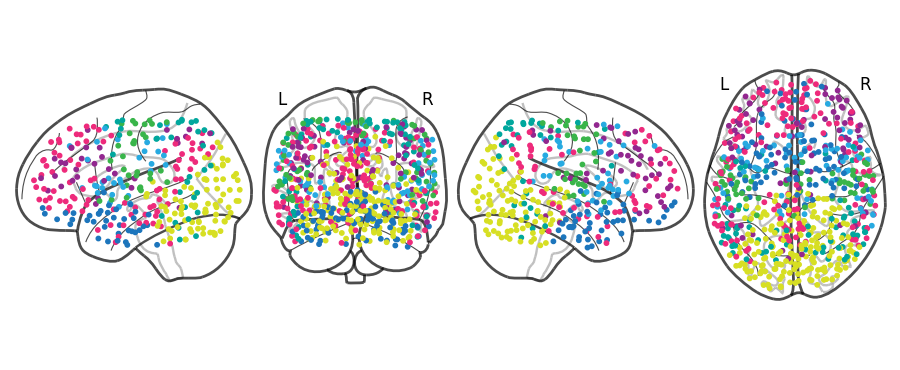

In [26]:
nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz')
plt.show()
plt.clf()

Ok now that we have the network labels for each of those nodes, lets see the overall count for each of those nodes in this dataset:

<Figure size 640x480 with 0 Axes>

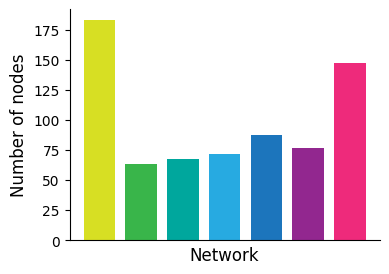

In [27]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes, x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
plt.show()
plt.clf()
fig.savefig(os.path.join('htfa_node_counts.pdf'), bbox_inches='tight')

In [40]:
intact_all_list = eval('intact_list')
paragraph_list = eval('paragraph_list')
word_all_list = eval('word_list')
rest_all_list = eval('rest_list')
try_stack_intact = np.hstack(intact_all_list)
try_stack_paragraph = np.hstack(paragraph_list)
try_stack_word =  np.hstack(word_all_list)
try_stack_rest =  np.hstack(rest_all_list)

RSS = 3026.034319738854
RSS = 3002.9351724581556
RSS = 2999.1325613218805
RSS = 2995.8702611497397
RSS = 2992.9593064897913
RSS = 2990.4103138430787
RSS = 2989.0869209855564
RSS = 2988.141703309032
RSS = 2987.6438551339975
RSS = 2987.4257790454126
RSS = 2987.2578311913157
RSS = 2987.187323514997
RSS = 2987.0569576459957
RSS = 2987.0943116963144
RSS = 2987.139642658229
RSS = 2987.1341431810215
RSS = 2987.226636826401
RSS = 2987.1399816357093
RSS = 2987.080424363152
RSS = 2987.1458117418497
RSS = 2975.143431817627
RSS = 2911.678349322379
RSS = 2899.7978383931204
RSS = 2893.7884095102095
RSS = 2890.1013132919657
RSS = 2887.942919488255
RSS = 2886.5846844055786
RSS = 2885.5059008908447
RSS = 2884.609268851461
RSS = 2883.842906814416
RSS = 2883.1311059696336
RSS = 2882.5474123191843
RSS = 2882.006605934034
RSS = 2881.5985662251596
RSS = 2881.157520723358
RSS = 2880.927444989264
RSS = 2880.693017018329
RSS = 2880.5493689824084
RSS = 2880.4100626289223
RSS = 2880.2622962027936
RSS = 2945.1815

<Figure size 640x480 with 0 Axes>

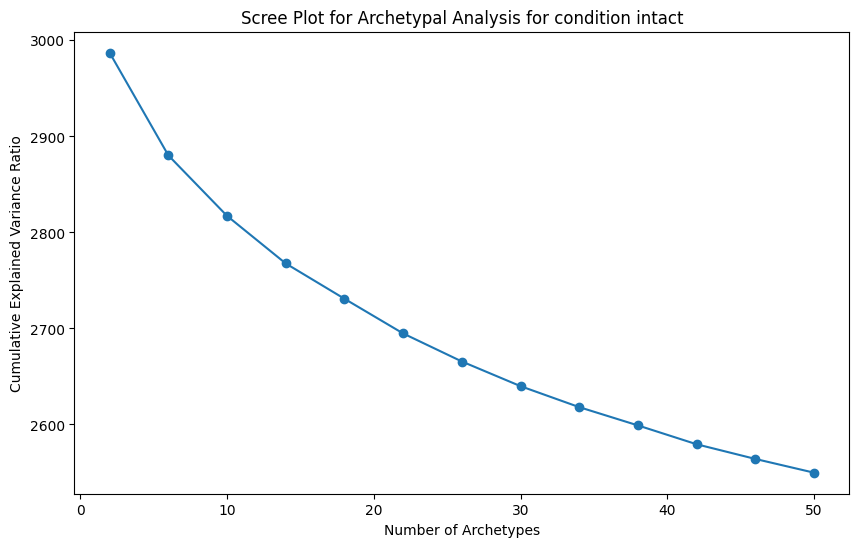

Archetypes DataFrame:
    n_archetypes condition                                         archetypes  \
0              2    intact  [[-0.15399787909939555, 1.263566078709478], [-...   
1              6    intact  [[0.5635314937370703, 0.5389233723293366, -0.9...   
2             10    intact  [[0.00818215604053271, 1.162834794343699, -1.1...   
3             14    intact  [[0.5761269065138513, 1.7790834376686961, -0.6...   
4             18    intact  [[0.7025376374803964, 2.0209953414943747, 1.40...   
5             22    intact  [[0.8938215778263684, 1.9986296672567527, 0.45...   
6             26    intact  [[0.6774782789691813, 2.610965379201108, -0.37...   
7             30    intact  [[0.652512263295943, 2.737233934726986, -0.805...   
8             34    intact  [[0.5873122991630417, 2.0676687426546696, -0.9...   
9             38    intact  [[-0.19270967953403706, 2.3049284760714968, -1...   
10            42    intact  [[-0.44154615913136275, 0.12590340885056014, -...   
11    

NameError: name 'coefficients_df' is not defined

In [54]:
n_archs = 54
n_over = 4
n_iters = 20

conds_listed = ['intact_list', 'paragraph_list', 'word_list', 'rest_list']

for u in conds_listed:
    
    num_archetypes=10
    n_node_clusters = 7
    data_list = eval(u)
    condition = u[:-5]

    archetypes_list = []
    coefficients_list = []
    reshaped_coeffs_list = []
    explained_variance_ratios = []
    
    # === CONCATENATE DATA FOR GROUP ANALYSIS ===
    group_data = np.hstack(data_list)
    
    # Loop through a range of potential archetype numbers (e.g., from 1 to 10)
    for n_archetypes in range(2, n_archs, n_over):  # Adjust the range as needed
        # === RUN ARCHETYPAL ANALYSIS ===
        aa = ArchetypalAnalysis(n_archetypes=n_archetypes,iterations=n_iters,tmax=300)
        aa.fit(group_data)
        archetypes = aa.archetypes()  # shape: (n_archetypes, n_features)
        coefficients = aa.transform(group_data)
        reshaped_coeffs = coefficients.reshape(np.array((n_archetypes, np.shape(data_list)[0], np.shape(data_list)[2])))

        # Store the coefficients (transformed data)
        archetypes_list.append(archetypes)
        coefficients_list.append(coefficients)
        reshaped_coeffs_list.append(reshaped_coeffs)
        
        
        # Store the explained variance ratio for the scree plot
        explained_variance_ratios.append(aa.score(group_data))  # Sum of explained variance

        
    # Create DataFrames from the stored lists
    archetypes_df = pd.DataFrame({'n_archetypes': range(2, n_archs, n_over), 'condition': c, 'archetypes': archetypes_list, 'coefficients': coefficients_list, 'reshaped_coefficients': reshaped_coeffs_list, 'explained_variance_ratios':explained_variance_ratios})
    
    # Create the scree plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, n_archs, n_over), explained_variance_ratios, marker='o')
    plt.title('Scree Plot for Archetypal Analysis for condition ' + c)
    plt.xlabel('Number of Archetypes')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.show()
    
    archetypes_df.to_csv("../data/archetypes/archetypes_df_" + c +".csv")

    
    # Print the DataFrames
    print("Archetypes DataFrame:")
    print(archetypes_df)
    



In [55]:
archetypes_df

,n_archetypes,condition,archetypes,coefficients,reshaped_coefficients,explained_variance_ratios
0,2,intact,"[[-0.15399787909939555, 1.263566078709478], [-...","[[0.6752823920265779, 0.5665116279069771, 0.86...","[[[0.6752823920265779, 0.5665116279069771, 0.8...",2987.145812
1,6,intact,"[[0.5635314937370703, 0.5389233723293366, -0.9...","[[0.10699889258028791, 0.028372093023255815, 0...","[[[0.10699889258028791, 0.028372093023255815, ...",2880.262296
2,10,intact,"[[0.00818215604053271, 1.162834794343699, -1.1...","[[0.23929125138427465, 0.0, 0.0966112956810631...","[[[0.23929125138427465, 0.0, 0.096611295681063...",2817.230018
3,14,intact,"[[0.5761269065138513, 1.7790834376686961, -0.6...","[[0.12489479512735338, 0.0, 0.0, 0.00673311184...","[[[0.12489479512735338, 0.0, 0.0, 0.0067331118...",2767.658055
4,18,intact,"[[0.7025376374803964, 2.0209953414943747, 1.40...","[[0.09926910299003322, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.09926910299003322, 0.0, 0.0, 0.0, 0.0, 0....",2730.915408
5,22,intact,"[[0.8938215778263684, 1.9986296672567527, 0.45...","[[0.06473975636766338, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.06473975636766338, 0.0, 0.0, 0.0, 0.0, 0....",2694.768158
6,26,intact,"[[0.6774782789691813, 2.610965379201108, -0.37...","[[0.03924695459579182, 0.0, 0.0, 0.0, 0.008150...","[[[0.03924695459579182, 0.0, 0.0, 0.0, 0.00815...",2665.576713
7,30,intact,"[[0.652512263295943, 2.737233934726986, -0.805...","[[0.02852713178294574, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.02852713178294574, 0.0, 0.0, 0.0, 0.0, 0....",2639.877232
8,34,intact,"[[0.5873122991630417, 2.0676687426546696, -0.9...","[[0.08850498338870437, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.08850498338870437, 0.0, 0.0, 0.0, 0.0, 0....",2618.031226
9,38,intact,"[[-0.19270967953403706, 2.3049284760714968, -1...","[[0.09289036544850497, 0.0, 0.0, 0.0, 0.117054...","[[[0.09289036544850497, 0.0, 0.0, 0.0, 0.11705...",2598.992885
